In [2]:
import torch.nn as nn



import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = mnist.load_data()

subset_size = 5000  # number of samples you want

X_train = X_train[:subset_size]
y_train = y_train[:subset_size]


X_test = X_test[:subset_size-4000]
y_test = y_test[:subset_size-4000]
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0


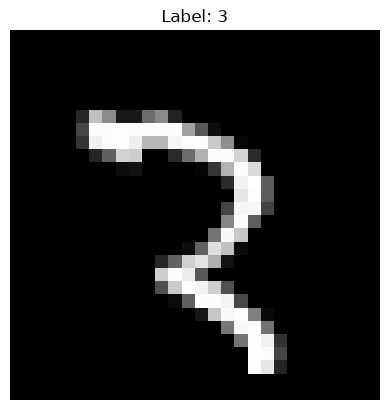

In [4]:
import matplotlib.pyplot as plt

plt.imshow(X_train[500], cmap='gray')
plt.title(f"Label: {y_train[500]}")
plt.axis('off')
plt.show()


In [5]:
X_test.shape

(1000, 28, 28)

In [6]:
y_train.shape

(5000,)

In [7]:
# # Convert labels to one-hot encoding
# y_train = to_categorical(y_train, 10)
# y_test = to_categorical(y_test, 10)


In [8]:
ann = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.summary()

E0000 00:00:1791126988.071888  216263 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3000)           │     2,355,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,366,010 (20.47 MB)

 Trainable params: 5,366,010 (20.47 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
ann.fit(X_train, y_train, epochs=3,batch_size=64)

Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8562 - loss: 0.4567
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9534 - loss: 0.1490
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9676 - loss: 0.1002


In [10]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.99      0.94        85
           1       0.99      0.98      0.98       126
           2       0.94      0.98      0.96       116
           3       0.93      0.93      0.93       107
           4       0.88      0.95      0.92       110
           5       0.96      0.87      0.92        87
           6       0.98      0.92      0.95        87
           7       0.94      0.96      0.95        99
           8       0.89      0.89      0.89        89
           9       0.95      0.85      0.90        94

    accuracy                           0.94      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.94      0.94      0.94      1000



In [11]:
cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu',
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [12]:
#Sigmoid
0.4
0.5
0.6

0.6

In [13]:
#Softmax
(0.4)/(0.4+0.5+0.6)


0.26666666666666666

In [14]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
cnn.fit(X_train, y_train, epochs=3)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8320 - loss: 0.5941
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9570 - loss: 0.1439
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9748 - loss: 0.0868


CNN's are best for image classification and gives superb accuracy. As, at the end 3 of epochs,

1.   Accuracy was at around 65% - a significant improvement over ANN
2.   Also, Extremly less computation compared to simple ANN
1.   As, Maxpooling reduces the image dimensions while still preserving the features.








In [16]:
cnn.evaluate(X_test,y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9710 - loss: 0.1003


[0.10027706623077393, 0.9710000157356262]

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Resize images
X_train_resized = tf.image.resize(X_train, (224, 224))
X_test_resized = tf.image.resize(X_test, (224, 224))

# Load pretrained VGG16 model (without top classifier)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Build classifier
vgg_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

vgg_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [18]:
# Convert grayscale (28x28) → RGB (28x28x3)
X_train_rgb = np.repeat(X_train[..., np.newaxis], 3, axis=-1)
X_test_rgb = np.repeat(X_test[..., np.newaxis], 3, axis=-1)

# Resize for InceptionNet (224x224)
X_train_incep = tf.image.resize(X_train_rgb, (224, 224)).numpy()
X_test_incep = tf.image.resize(X_test_rgb, (224, 224)).numpy()

print("X_train_rgb shape:", X_train_rgb.shape)
print("X_test_rgb shape:", X_test_rgb.shape)

X_train_rgb shape: (5000, 28, 28, 3)
X_test_rgb shape: (1000, 28, 28, 3)


In [19]:
print("X_train_incep shape:", X_train_incep.shape)
print("X_test_incep shape:", X_test_incep.shape)

X_train_incep shape: (5000, 224, 224, 3)
X_test_incep shape: (1000, 224, 224, 3)


In [20]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam



# Load base Inception model
base_model_incep = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze convolutional base
for layer in base_model_incep.layers:
    layer.trainable = False

# Add classifier head
inception_model = Sequential([
    base_model_incep,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

inception_model.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

inception_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,857,002 (87.19 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

datagen.fit(X_train_incep)

history_incep = inception_model.fit(
    datagen.flow(X_train_incep, y_train, batch_size=64),
    epochs=3,
    validation_data=(X_test_incep, y_test)
)


Epoch 1/3


I0000 00:00:1791127053.422837  216263 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


79/79 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.5274 - loss: 1.4423 - val_accuracy: 0.7900 - val_loss: 0.8360
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.7410 - loss: 0.8171 - val_accuracy: 0.8120 - val_loss: 0.6189
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.8050 - loss: 0.6394 - val_accuracy: 0.8590 - val_loss: 0.4938


In [24]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vggPreprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnetPreprocess
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [25]:
(xTrainFull, yTrainFull), (xTest, yTest) = cifar10.load_data()
yTrainFull = yTrainFull.flatten()
yTest = yTest.flatten()

trainSize = 10000
valSize = 2000
testSize = 2000

xTrain, yTrain = xTrainFull[:trainSize], yTrainFull[:trainSize]
xVal, yVal = xTrainFull[trainSize:trainSize + valSize], yTrainFull[trainSize:trainSize + valSize]
xTest, yTest = xTest[:testSize], yTest[:testSize]

classNames = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']

print(xTrain.shape, xVal.shape, xTest.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2370s 14us/step
(10000, 32, 32, 3) (2000, 32, 32, 3) (2000, 32, 32, 3)


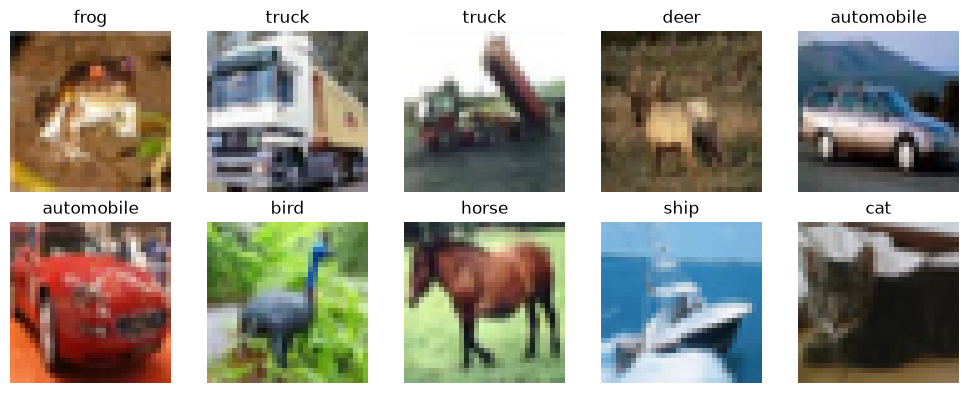

In [26]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(xTrain[i])
    plt.title(classNames[yTrain[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [27]:
imgSize = 128
batchSize = 64

def makeDataset(xData, yData, preprocessFn, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((xData, yData))
    if shuffle:
        ds = ds.shuffle(len(xData), seed=42)

    def prepare(img, label):
        img = tf.image.resize(tf.cast(img, tf.float32), (imgSize, imgSize))
        return preprocessFn(img), label

    return ds.map(prepare, num_parallel_calls=tf.data.AUTOTUNE).batch(batchSize).prefetch(tf.data.AUTOTUNE)

vggTrainDs = makeDataset(xTrain, yTrain, vggPreprocess, shuffle=True)
vggValDs = makeDataset(xVal, yVal, vggPreprocess)
vggTestDs = makeDataset(xTest, yTest, vggPreprocess)

resnetTrainDs = makeDataset(xTrain, yTrain, resnetPreprocess, shuffle=True)
resnetValDs = makeDataset(xVal, yVal, resnetPreprocess)
resnetTestDs = makeDataset(xTest, yTest, resnetPreprocess)

In [28]:
def buildModel(baseModelClass):
    baseModel = baseModelClass(weights='imagenet', include_top=False,
                               input_shape=(imgSize, imgSize, 3))
    baseModel.trainable = False

    inputs = layers.Input(shape=(imgSize, imgSize, 3))
    x = layers.RandomFlip('horizontal')(inputs)
    x = baseModel(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs, outputs), baseModel


def compileModel(model, learningRate):
    model.compile(optimizer=Adam(learning_rate=learningRate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


def unfreezeFrom(baseModel, startLayerName):
    baseModel.trainable = True
    found = False
    for layer in baseModel.layers:
        if layer.name == startLayerName:
            found = True
        layer.trainable = found and not isinstance(layer, layers.BatchNormalization)

In [29]:
vggModel, vggBase = buildModel(VGG16)
compileModel(vggModel, learningRate=1e-3)
vggHistory1 = vggModel.fit(vggTrainDs, validation_data=vggValDs, epochs=5)

Epoch 1/5


/home/muhammad-hamza/PC/Drive 1/p230577/python/Deep learning/CP3/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


157/157 ━━━━━━━━━━━━━━━━━━━━ 536s 3s/step - accuracy: 0.5914 - loss: 1.7042 - val_accuracy: 0.7680 - val_loss: 0.6864
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 728s 5s/step - accuracy: 0.7433 - loss: 0.7775 - val_accuracy: 0.8005 - val_loss: 0.5746
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 759s 5s/step - accuracy: 0.7901 - loss: 0.6197 - val_accuracy: 0.8240 - val_loss: 0.5289
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 742s 5s/step - accuracy: 0.8196 - loss: 0.5258 - val_accuracy: 0.8360 - val_loss: 0.4967
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 710s 5s/step - accuracy: 0.8395 - loss: 0.4657 - val_accuracy: 0.8260 - val_loss: 0.4998


In [30]:
unfreezeFrom(vggBase, 'block5_conv1')
compileModel(vggModel, learningRate=1e-5)
vggHistory2 = vggModel.fit(vggTrainDs, validation_data=vggValDs, epochs=5)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 821s 5s/step - accuracy: 0.8655 - loss: 0.3911 - val_accuracy: 0.8525 - val_loss: 0.4539
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 792s 5s/step - accuracy: 0.8945 - loss: 0.3038 - val_accuracy: 0.8570 - val_loss: 0.4319
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.9103 - loss: 0.2615 - val_accuracy: 0.8635 - val_loss: 0.4172
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 550s 4s/step - accuracy: 0.9273 - loss: 0.2114 - val_accuracy: 0.8630 - val_loss: 0.4262
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.9337 - loss: 0.1842 - val_accuracy: 0.8805 - val_loss: 0.4092


In [32]:
resnetModel, resnetBase = buildModel(ResNet50)
compileModel(resnetModel, learningRate=1e-3)
resnetHistory1 = resnetModel.fit(resnetTrainDs, validation_data=resnetValDs, epochs=5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 62s 1us/step
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7522 - loss: 0.7745 - val_accuracy: 0.8550 - val_loss: 0.4378
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8414 - loss: 0.4713 - val_accuracy: 0.8705 - val_loss: 0.3929
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.8624 - loss: 0.4084 - val_accuracy: 0.8650 - val_loss: 0.4155
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.8843 - loss: 0.3471 - val_accuracy: 0.8800 - val_loss: 0.3964
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8919 - loss: 0.3118 - val_accuracy: 0.8755 - val_loss: 0.4021


In [33]:
unfreezeFrom(resnetBase, 'conv5_block1_1_conv')
compileModel(resnetModel, learningRate=1e-5)
resnetHistory2 = resnetModel.fit(resnetTrainDs, validation_data=resnetValDs, epochs=5)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9173 - loss: 0.2461 - val_accuracy: 0.8910 - val_loss: 0.3584
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9391 - loss: 0.1787 - val_accuracy: 0.8895 - val_loss: 0.3617
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.9543 - loss: 0.1328 - val_accuracy: 0.8905 - val_loss: 0.3727
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.9677 - loss: 0.0988 - val_accuracy: 0.8940 - val_loss: 0.3799
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9705 - loss: 0.0797 - val_accuracy: 0.8985 - val_loss: 0.3943


In [ ]:
vggTestLoss, vggTestAcc = vggModel.evaluate(vggTestDs, verbose=0)
resnetTestLoss, resnetTestAcc = resnetModel.evaluate(resnetTestDs, verbose=0)

print(f"VGG16    -> test acc: {vggTestAcc:.4f} | test loss: {vggTestLoss:.4f}")
print(f"ResNet50 -> test acc: {resnetTestAcc:.4f} | test loss: {resnetTestLoss:.4f}")

vggPred = np.argmax(vggModel.predict(vggTestDs, verbose=0), axis=1)
resnetPred = np.argmax(resnetModel.predict(resnetTestDs, verbose=0), axis=1)

print("\nVGG16:\n", classification_report(yTest, vggPred, target_names=classNames))
print("\nResNet50:\n", classification_report(yTest, resnetPred, target_names=classNames))

In [ ]:
def joinHistory(h1, h2, key):
    return h1.history[key] + h2.history[key]

vggTrainAcc = joinHistory(vggHistory1, vggHistory2, 'accuracy')
vggValAcc = joinHistory(vggHistory1, vggHistory2, 'val_accuracy')
resnetTrainAcc = joinHistory(resnetHistory1, resnetHistory2, 'accuracy')
resnetValAcc = joinHistory(resnetHistory1, resnetHistory2, 'val_accuracy')

phaseSplit = len(vggHistory1.history['accuracy'])

plt.figure(figsize=(10, 5))
plt.plot(vggTrainAcc, '--', label='VGG16 train')
plt.plot(vggValAcc, label='VGG16 val')
plt.plot(resnetTrainAcc, '--', label='ResNet50 train')
plt.plot(resnetValAcc, label='ResNet50 val')
plt.axvline(phaseSplit - 0.5, color='gray', linestyle=':', label='fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 vs ResNet50 on CIFAR10')
plt.legend()
plt.grid(alpha=0.3)
plt.show()